# Part A: The Foundation — Standard Workflow
## Task 1: Data Preparation
### Importing Libraries

In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

## Task 2: Preprocessing
### Loading and Resizing Images (64x64, RGB)
    

In [2]:
def load_images(directory, image_size=(64, 64)):
    X_values = []
    y_values = []
    
    folders = sorted([f for f in os.listdir(directory) if not f.startswith('.')])
    
    for i, each_folder in enumerate(folders):
        sub_path = os.path.join(directory, each_folder)
        for each_image in sorted(os.listdir(sub_path)):
            if not each_image.startswith('.'):
                full_path = os.path.join(sub_path, each_image)
                image = cv2.imread(full_path)
                if image is None:
                    continue
                image = cv2.resize(image, image_size)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                X_values.append(image)
                y_values.append(i)
    
    return np.array(X_values), np.array(y_values)

### Creating X and y Arrays

In [3]:
# Load train and validation
X_train_raw, y_train = load_images('project_data/train', image_size= (64, 64))
X_val_raw,   y_val   = load_images('project_data/valid', image_size= (64, 64))
X_test_raw,  y_test  = load_images('project_data/test', image_size= (64, 64))   

# Save class names for later (for classification report)
class_names = sorted([f for f in os.listdir('project_data/train') if not f.startswith('.')])

print(f"X_train shape: {X_train_raw.shape}")
print(f"X_val shape:   {X_val_raw.shape}")
print(f"X_test shape:  {X_test_raw.shape}")
print(f"Total classes: {len(class_names)}")

X_train shape: (7624, 64, 64, 3)
X_val shape:   (265, 64, 64, 3)
X_test shape:  (265, 64, 64, 3)
Total classes: 53


## Task 3: Visualization — Sanity Check

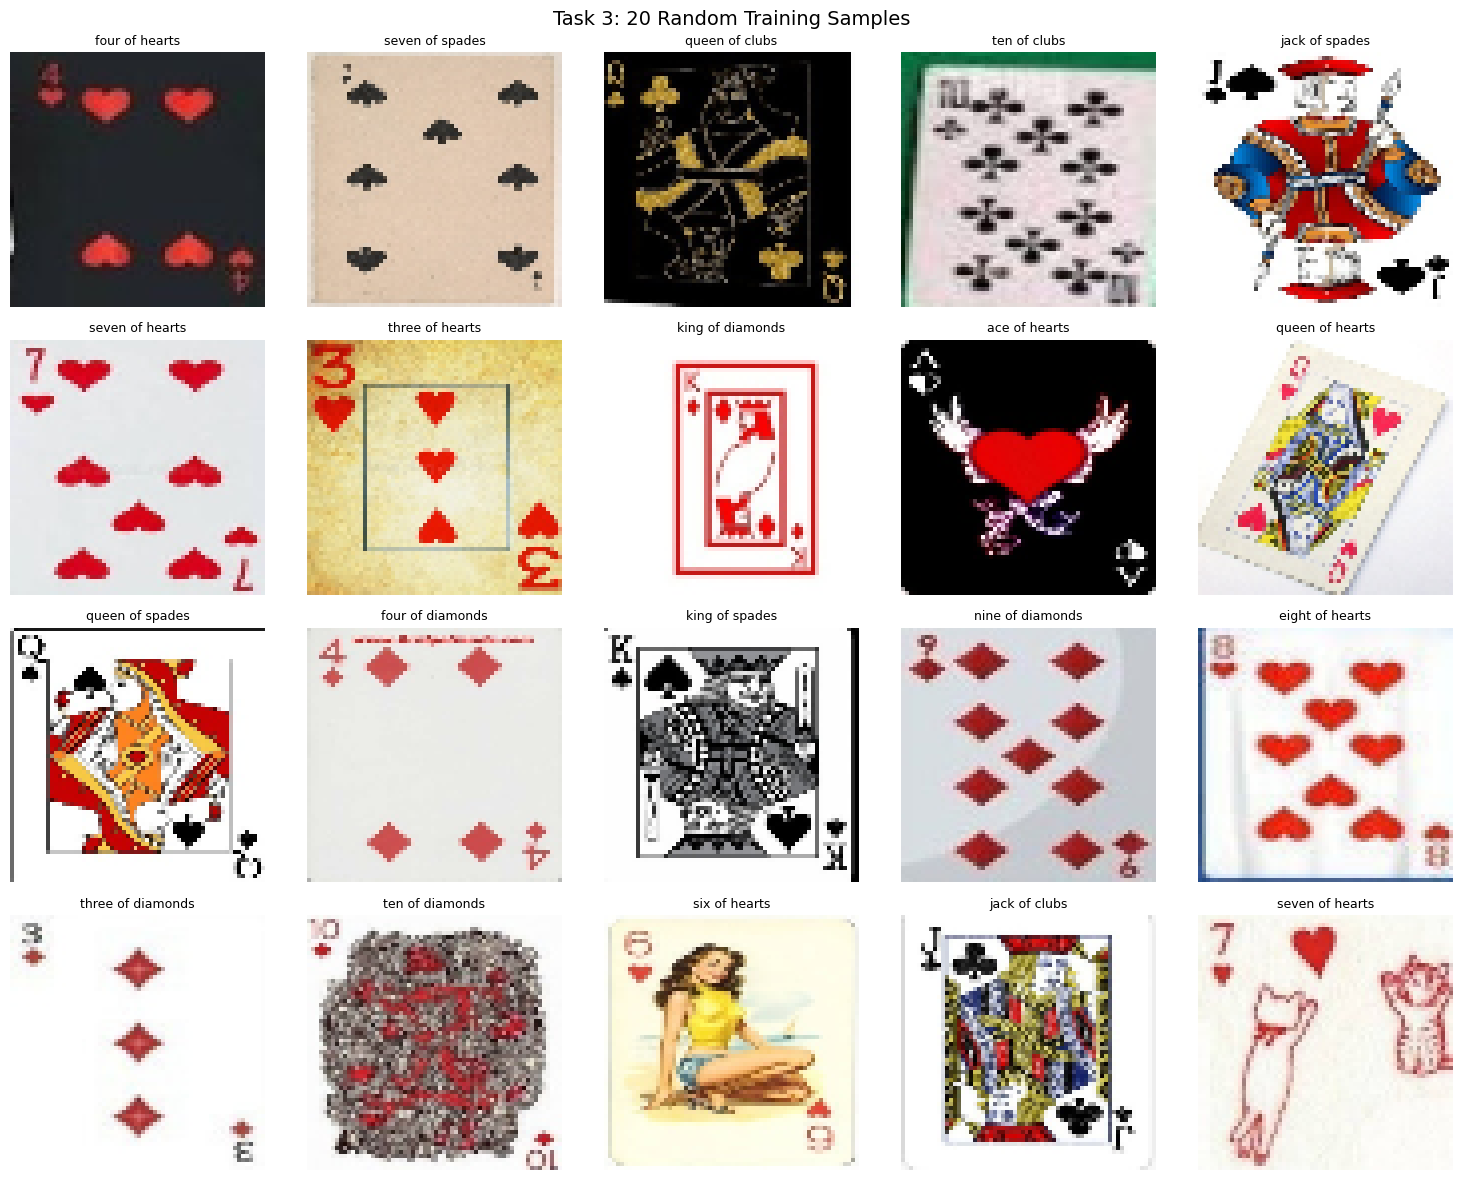

In [4]:
# Task 3: Sanity Check — display 20 random samples
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

# Pick 20 random indices from training set
random_indices = np.random.choice(len(X_train_raw), 20, replace=False)

for i, idx in enumerate(random_indices):
    axes[i].imshow(X_train_raw[idx])
    axes[i].set_title(class_names[y_train[idx]], fontsize=9)
    axes[i].axis('off')

plt.suptitle('Task 3: 20 Random Training Samples', fontsize=14)
plt.tight_layout()
plt.show()

## Task 4: Normalization & Splits
### Scaling pixels to 0-1 and reshaping to 4D tensor

In [5]:
# Task 4: Normalize pixel values to 0-1
X_train = X_train_raw / 255.0
X_val   = X_val_raw   / 255.0
X_test  = X_test_raw  / 255.0

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Pixel min: {X_train.min()}, max: {X_train.max()}")

X_train shape: (7624, 64, 64, 3)
X_val shape:   (265, 64, 64, 3)
X_test shape:  (265, 64, 64, 3)
Pixel min: 0.0, max: 1.0


## Task 5: CNN Modeling
### Building the CNN Architecture (Conv2D → Flatten → Dense)

In [6]:
# Task 5: Build CNN Model
num_classes = 53

model = Sequential()

# Only 1 Conv2D block (simpler model)
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Classifier
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

c:\Users\hoshenghong\miniconda3\envs\CVE\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 53)             │         6,837 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,202,165 (16.03 MB)

 Trainable params: 4,202,165 (16.03 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Train
history = model.fit(X_train,
                    y_train,
                    epochs=15,
                    validation_data=(X_val, y_val),
                    verbose=1)

Epoch 1/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.1386 - loss: 3.5532 - val_accuracy: 0.3509 - val_loss: 2.2439
Epoch 2/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.4294 - loss: 2.1478 - val_accuracy: 0.5434 - val_loss: 1.6610
Epoch 3/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.5631 - loss: 1.6164 - val_accuracy: 0.5925 - val_loss: 1.4506
Epoch 4/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.6659 - loss: 1.2330 - val_accuracy: 0.6528 - val_loss: 1.3465
Epoch 5/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.7504 - loss: 0.9120 - val_accuracy: 0.6604 - val_loss: 1.3100
Epoch 6/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.8183 - loss: 0.6631 - val_accuracy: 0.6981 - val_loss: 1.3618
Epoch 7/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.8774 - loss: 0.4722 - val_accuracy: 0.6566 - val_loss: 1.3968
Epoch 8/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9230 - loss: 0.3322 - val_ac

## Task 6: Evaluation
### Training vs Validation Loss and Accuracy Curves

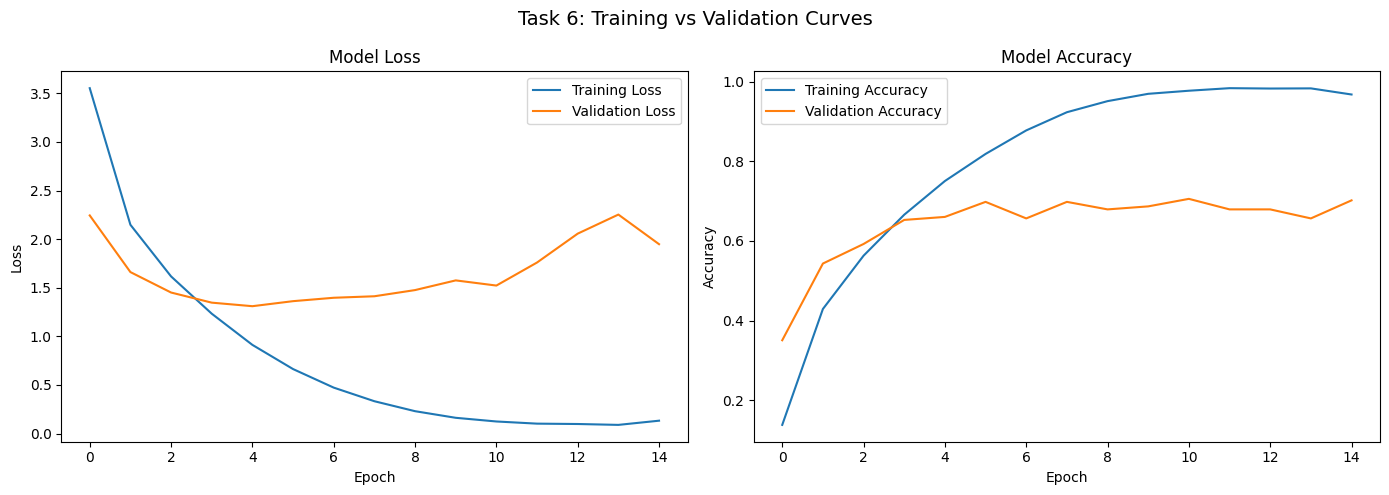

In [8]:
# Task 6: Plot Training vs Validation Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Task 6: Training vs Validation Curves', fontsize=14)
plt.tight_layout()
plt.show()

### Predicting on Test Set and Classification Report

In [9]:
# Predict on Test Set
y_pred = model.predict(X_test).argmax(axis=1)

# Classification Report
print(classification_report(y_true=y_test,
                            y_pred=y_pred,
                            target_names=class_names))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
                   precision    recall  f1-score   support

     ace of clubs       0.67      0.80      0.73         5
  ace of diamonds       0.80      0.80      0.80         5
    ace of hearts       1.00      0.80      0.89         5
    ace of spades       0.50      1.00      0.67         5
   eight of clubs       0.75      0.60      0.67         5
eight of diamonds       0.71      1.00      0.83         5
  eight of hearts       1.00      0.80      0.89         5
  eight of spades       0.36      1.00      0.53         5
    five of clubs       0.60      0.60      0.60         5
 five of diamonds       1.00      0.80      0.89         5
   five of hearts       1.00      0.80      0.89         5
   five of spades       1.00      0.80      0.89         5
    four of clubs       0.50      0.80      0.62         5
 four of diamonds       1.00      0.80      0.89         5
   four of hearts       1.00      1.00      1.00         5
   four of spades

c:\Users\hoshenghong\miniconda3\envs\CVE\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hoshenghong\miniconda3\envs\CVE\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hoshenghong\miniconda3\envs\CVE\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r